# Подготовка шаблона для рисования


In [2]:
%load_ext autoreload
%autoreload 2

import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from utils import generate_template, overlay_character, template_meta

# --- параметры шаблона (менять здесь) ---
CANVAS_SIZE = (1240, 1754)  # A4 @ 150 DPI (h, w)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

TITLE = "Sketch Factory"
OUTPUT_DIR = "output"

# что из этого вычисляется (для проверки)
meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)
print(f"Canvas:       {CANVAS_SIZE[1]}×{CANVAS_SIZE[0]}")
print(f"Drawing bbox: {meta['drawing_bbox']}")
print(f"Markers:      {meta['marker_centers']}")

Canvas:       1754×1240
Drawing bbox: [150, 150, 1454, 940]
Markers:      [[100.0, 100.0], [1654.0, 100.0], [1654.0, 1140.0], [100.0, 1140.0]]


## Пустой А4

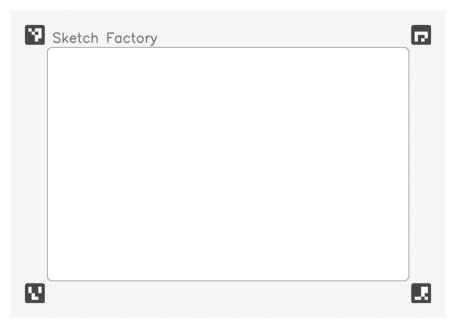

Сохранено: output\template.png


In [22]:
result = generate_template(
    output_path=f"{OUTPUT_DIR}/template.png",
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
    title=TITLE,
)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result["template"], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"Сохранено: {result['template_path']}")

## Наложение персонажа

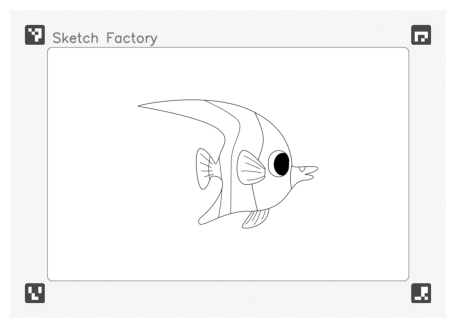

Сохранено: output/img05_template.png
image_rect: [345, 244, 1064, 752]


In [29]:
img_path = "input/img05.png"  # путь к PNG/JPG персонажа

result_char = overlay_character(
    template_path=f"{OUTPUT_DIR}/template.png",
    img_path=img_path,
    output_path=f"{OUTPUT_DIR}/{Path(img_path).stem}_template.png",
    content_scale=0.8,
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
)

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(result_char["template"], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"Сохранено: {result_char['output_path']}")
print(f"image_rect: {result_char['image_rect']}")

In [4]:
img_path = "input/img05.png" 

In [7]:
import json
import numpy as np

# шаблон скелета — какие точки размечать и как соединять
SKELETON = {
    "points": [
        "nose",         # 0 — нос/рот
        "center",       # 1 — центр тела
        "tail_base",    # 2 — где хвост начинается
        "tail_tip",     # 3 — кончик хвоста
        "top_fin",      # 4 — верхний плавник
        "bottom_fin",   # 5 — нижний плавник
    ],
    "bones": [
        (0, 1),  # nose → center
        (1, 2),  # center → tail_base
        (2, 3),  # tail_base → tail_tip
        (1, 4),  # center → top_fin
        (1, 5),  # center → bottom_fin
    ],
}


# загружаем оригинальный PNG персонажа
char_img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
ih, iw = char_img.shape[:2]

# подготовка: RGBA → BGR с белым фоном
if char_img.shape[2] == 4:
    alpha = char_img[:, :, 3:4] / 255.0
    bgr = char_img[:, :, :3]
    display_base = (bgr * alpha + 255 * (1 - alpha)).astype(np.uint8)
else:
    display_base = char_img.copy()

# --- интерактивная разметка ---
clicked = []

def redraw():
    display = display_base.copy()
    for a, b in SKELETON["bones"]:
        if a < len(clicked) and b < len(clicked):
            cv2.line(display, clicked[a], clicked[b], (0, 50, 255), 3)
    for i, pt in enumerate(clicked):
        cv2.circle(display, pt, 6, (0, 0, 255), -1)
        cv2.circle(display, pt, 6, (255, 255, 255), 2)
        cv2.putText(display, SKELETON["points"][i], (pt[0]+10, pt[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 180, 0), 1)
    n = len(clicked)
    total = len(SKELETON["points"])
    if n < total:
        txt = f"Click: {SKELETON['points'][n]} ({n}/{total}) | RMB=undo"
    else:
        txt = f"Done ({total}/{total})! Press any key"
    cv2.putText(display, txt, (10, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 180, 255), 2)
    cv2.imshow("Skeleton Markup", display)

def on_mouse(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN and len(clicked) < len(SKELETON["points"]):
        clicked.append((x, y))
        redraw()
    elif event == cv2.EVENT_RBUTTONDOWN and clicked:
        clicked.pop()
        redraw()

redraw()
cv2.setMouseCallback("Skeleton Markup", on_mouse)
cv2.waitKey(0)
cv2.destroyAllWindows()

# нормализованные координаты (0..1)
keypoints = {}
for name, (x, y) in zip(SKELETON["points"], clicked):
    keypoints[name] = [round(x / iw, 4), round(y / ih, 4)]

print("Размеченные точки (нормализованные):")
for name, (nx, ny) in keypoints.items():
    print(f"  {name:16s}  ({nx:.4f}, {ny:.4f})")


Размеченные точки (нормализованные):
  nose              (0.7838, 0.5529)
  center            (0.5238, 0.5311)
  tail_base         (0.4525, 0.5277)
  tail_tip          (0.3872, 0.4739)
  top_fin           (0.2411, 0.1832)
  bottom_fin        (0.4323, 0.7866)


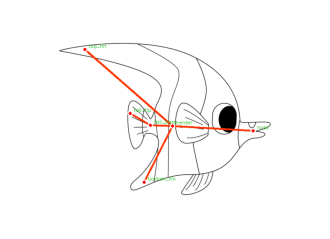

True

In [23]:
display = display_base.copy()
for a, b in SKELETON["bones"]:
    if a < len(clicked) and b < len(clicked):
        cv2.line(display, clicked[a], clicked[b], (0, 50, 255), 3)
for i, pt in enumerate(clicked):
    cv2.circle(display, pt, 6, (0, 0, 255), -1)
    cv2.circle(display, pt, 6, (255, 255, 255), 2)
    cv2.putText(display, SKELETON["points"][i], (pt[0]+10, pt[1]-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 180, 0), 1)

plt.figure(figsize=(4, 5))
plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

cv2.imwrite(f"{OUTPUT_DIR}/{Path(img_path).stem}_skeleton.png", display)


In [9]:
skeleton_data = {
    "image": img_path,
    "image_size": [iw, ih],
    "skeleton": SKELETON,
    "keypoints": keypoints,
}

out_json = f"{OUTPUT_DIR}/{Path(img_path).stem}_skeleton.json"
Path(out_json).parent.mkdir(parents=True, exist_ok=True)
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(skeleton_data, f, indent=2, ensure_ascii=False)

print(f"Сохранено: {out_json}")


Сохранено: output/img05_skeleton.json


In [12]:
img_rgba = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
if img_rgba.shape[2] == 3:
    img_rgba = cv2.cvtColor(img_rgba, cv2.COLOR_BGR2BGRA)


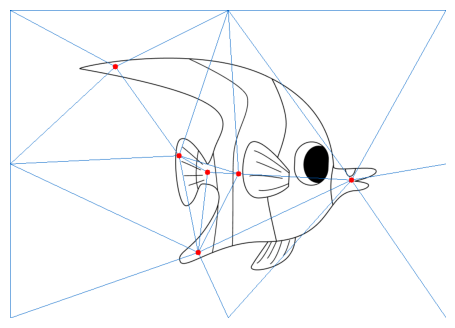

18 треугольников, 14 точек (6 подвижных)


True

In [ ]:
from scipy.spatial import Delaunay

# контрольные точки = скелет + углы + серединки краёв
corners = [
    [0, 0], [iw, 0], [iw, ih], [0, ih],
    [iw//2, 0], [iw, ih//2], [iw//2, ih], [0, ih//2],
]

ctrl_names = list(SKELETON["points"])
ctrl_pts = np.array([[kp[0]*iw, kp[1]*ih] for kp in keypoints.values()], dtype=np.float32)
ctrl_pts = np.vstack([ctrl_pts, np.array(corners, dtype=np.float32)])
n_kp = len(SKELETON["points"])  # первые n_kp подвижные, остальные — якоря

tri = Delaunay(ctrl_pts)

# визуализация
vis = display_base.copy()
for simplex in tri.simplices:
    pts = ctrl_pts[simplex].astype(np.int32)
    cv2.polylines(vis, [pts], True, (200, 100, 0), 1)
for pt in ctrl_pts[:n_kp]:
    cv2.circle(vis, pt.astype(int).tolist(), 5, (0, 0, 255), -1)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()
print(f"{len(tri.simplices)} треугольников, {len(ctrl_pts)} точек ({n_kp} подвижных)")

cv2.imwrite(f"{OUTPUT_DIR}/{Path(img_path).stem}_triangulation.png", vis)

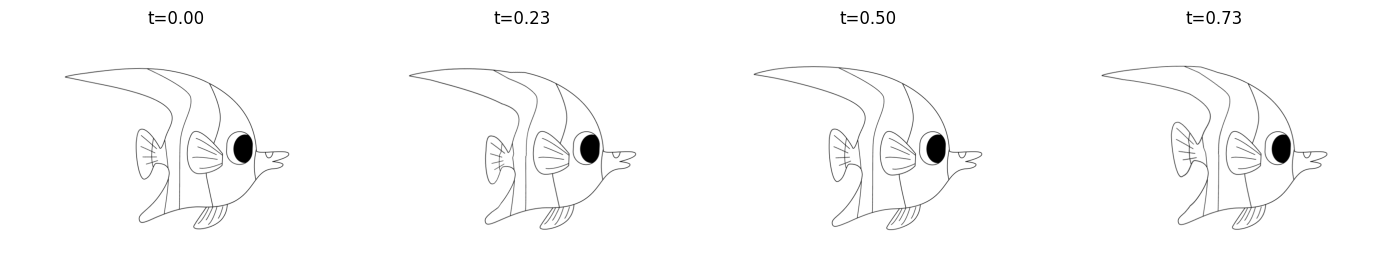

Сохранено: output/img05_anim.gif (30 кадров, 2s)


In [17]:
from PIL import Image

FPS = 15
DURATION = 2  # секунд


def make_motion(t, base_pts, n_kp, names):
    pts = base_pts.copy()
    a = t * 2 * np.pi
    idx = {name: i for i, name in enumerate(names)}

    if "tail_base" in idx:
        pts[idx["tail_base"], 1] += np.sin(a) * 8
    if "tail_tip" in idx:
        pts[idx["tail_tip"], 0] += np.sin(a) * 10
        pts[idx["tail_tip"], 1] += np.sin(a) * 20
    if "top_fin" in idx:
        pts[idx["top_fin"], 0] += np.sin(a + np.pi*0.5) * 8
        pts[idx["top_fin"], 1] += np.sin(a + np.pi*0.5) * 5
    if "bottom_fin" in idx:
        pts[idx["bottom_fin"], 1] += np.sin(a - np.pi*0.5) * 6
    if "nose" in idx:
        pts[idx["nose"], 0] += np.sin(a) * 3

    return pts


def warp_triangle(src_img, src_tri, dst_tri, dst_img):
    r = cv2.boundingRect(np.float32([dst_tri]))
    x, y, w, h = r
    if w <= 0 or h <= 0:
        return
    x2 = min(x + w, dst_img.shape[1])
    y2 = min(y + h, dst_img.shape[0])
    x, y = max(x, 0), max(y, 0)
    w, h = x2 - x, y2 - y
    if w <= 0 or h <= 0:
        return

    dst_local = np.float32([(p[0]-x, p[1]-y) for p in dst_tri])
    M = cv2.getAffineTransform(np.float32(src_tri), dst_local)
    warped = cv2.warpAffine(src_img, M, (w, h), flags=cv2.INTER_LINEAR,
                            borderMode=cv2.BORDER_REFLECT_101)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, np.int32(dst_local), 255)

    roi = dst_img[y:y2, x:x2]
    m = mask[:roi.shape[0], :roi.shape[1]] > 0
    warped = warped[:roi.shape[0], :roi.shape[1]]
    for c in range(dst_img.shape[2]):
        roi[:, :, c] = np.where(m, warped[:, :, c], roi[:, :, c])


# подготовка RGBA
img_rgba = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
if img_rgba.shape[2] == 3:
    img_rgba = cv2.cvtColor(img_rgba, cv2.COLOR_BGR2BGRA)

# рендерим кадры
n_frames = FPS * DURATION
frames = []
for i in range(n_frames):
    t = i / n_frames
    dst_pts = make_motion(t, ctrl_pts, n_kp, SKELETON["points"])
    dst_img = np.zeros_like(img_rgba)
    for simplex in tri.simplices:
        warp_triangle(img_rgba, ctrl_pts[simplex].tolist(),
                      dst_pts[simplex].tolist(), dst_img)
    frames.append(dst_img)

# превью
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, fi in zip(axes, [0, n_frames//4, n_frames//2, 3*n_frames//4]):
    ax.imshow(cv2.cvtColor(frames[fi], cv2.COLOR_BGRA2RGBA))
    ax.set_title(f"t={fi/n_frames:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

# сохраняем GIF
out_gif = f"{OUTPUT_DIR}/{Path(img_path).stem}_anim.gif"
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
pil_frames[0].save(out_gif, save_all=True, append_images=pil_frames[1:],
                   duration=1000//FPS, loop=0, disposal=2)
print(f"Сохранено: {out_gif} ({n_frames} кадров, {DURATION}s)")


In [22]:
def make_wave_flip_frames(img, n_frames=40):
    """Волновой переворот справа налево — как бумажку переворачивают."""
    h, w = img.shape[:2]
    flip_frames = []

    for i in range(n_frames):
        t = i / (n_frames - 1)
        result = np.zeros_like(img)

        for col in range(w):
            delay = (1 - col / w) * 0.6  # правый край первым
            local_t = (t - delay) / (1 - 0.6)
            local_t = np.clip(local_t, 0, 1)

            angle = local_t * np.pi
            scale_y = abs(np.cos(angle))
            if scale_y < 0.01:
                continue

            cy = h / 2
            for dst_y in range(h):
                src_y = int(cy + (dst_y - cy) / scale_y)
                if 0 <= src_y < h:
                    result[dst_y, col] = img[src_y, col]

        flip_frames.append(result)

    return flip_frames

flip = make_wave_flip_frames(frames[-1], n_frames=40)
all_frames = frames + flip

out_gif = f"{OUTPUT_DIR}/{Path(img_path).stem}_anim.gif"
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in all_frames]
pil_frames[0].save(out_gif, save_all=True, append_images=pil_frames[1:],
                   duration=1000//FPS, loop=0, disposal=2)
print(f"Сохранено: {out_gif} ({len(all_frames)} кадров)")

Сохранено: output/img05_anim.gif (70 кадров)
